In [1]:
%matplotlib inline 
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina' # I use a HiDPI screen

In [1]:
import sys
sys.path.insert(0, "/home/quantumer/dmde_class_perturb-CEDE/python/build/lib.linux-x86_64-3.10")
import subprocess

import classy
print("classy imported from: \n",classy.__file__)
from fishchips.experiments import CMB_Primary
from fishchips.cosmo import Observables
import fishchips.util

from classy import Class  # CLASS python wrapper
import numpy as np
import matplotlib.pyplot as plt

classy imported from: 
 /home/quantumer/dmde_class_perturb-CEDE/python/build/lib.linux-x86_64-3.10/classy.cpython-310-x86_64-linux-gnu.so


## Initialization
We start with the usual setup, generating an `Observables` object and computing a fiducial.

In [2]:
# create an Observables object to store information for derivatives

# For phi_scf_ini convergence, use a physically relevant fiducial (not near zero).
pars = ['phi_scf_ini', 'frac_dmde', 'g_scf', 'm_scf']
centers = np.array([0.695, 1e-8, 1e-8, 0])
steps = np.array([0.01, 0.001, 0.001, 0.01])

obs = Observables(parameters=pars,
                  fiducial=centers,
                  left=centers,
                  right=centers + steps)

# Template CLASS configuration
classy_template = {'output': 'tCl pCl lCl',
                   'l_max_scalars': 3500,
                   'h': 0.6732117,
                   'omega_b': 0.02238280,
                   'omega_cdm': 0.12038,
                  #  'g_scf': -0.1,
                  #  'm_scf': 14.3,
                #    'frac_dmde': 1e-3,
                   'N_ur': 2.0328,
                   'omega_ncdm': 0.0006451439,
                   'N_ncdm': 1,
                   'm_ncdm': 0.06,
                   'T_ncdm': 0.71611,
                   'tau_reio': 0.05430842,
                   'Omega_k': 0.0,
                   'A_s': 2.100549e-09,
                   'n_s': 0.9660499,
                   'YHe': 0.2454006,
                   'lensing': 'yes',
                   'gauge': 'synchronous'}

# Add fiducial values and compute baseline cosmology
classy_template.update(dict(zip(obs.parameters, obs.fiducial)))
obs.compute_cosmo(key='fiducial', classy_dict=classy_template)

## Checking Derivatives

In order to check derivative convergence, we use `check_deriv_compute` and `check_deriv_plot` with a sequence of step sizes.

For `phi_scf_ini`, avoid testing around a decoupled point (`g_scf = 0`) or with additive steps that are huge compared to the fiducial value. Use relative steps around a coupled fiducial point instead.

{'output': 'tCl pCl lCl', 'l_max_scalars': 3500, 'h': 0.6732117, 'omega_b': 0.0223828, 'omega_cdm': 0.12038, 'N_ur': 2.0328, 'omega_ncdm': 0.0006451439, 'N_ncdm': 1, 'm_ncdm': 0.06, 'T_ncdm': 0.71611, 'tau_reio': 0.05430842, 'Omega_k': 0.0, 'A_s': 2.100549e-09, 'n_s': 0.9660499, 'YHe': 0.2454006, 'lensing': 'yes', 'gauge': 'synchronous', 'phi_scf_ini': 0.695, 'frac_dmde': 1e-08, 'g_scf': 1e-08, 'm_scf': 0.02}
{'output': 'tCl pCl lCl', 'l_max_scalars': 3500, 'h': 0.6732117, 'omega_b': 0.0223828, 'omega_cdm': 0.12038, 'N_ur': 2.0328, 'omega_ncdm': 0.0006451439, 'N_ncdm': 1, 'm_ncdm': 0.06, 'T_ncdm': 0.71611, 'tau_reio': 0.05430842, 'Omega_k': 0.0, 'A_s': 2.100549e-09, 'n_s': 0.9660499, 'YHe': 0.2454006, 'lensing': 'yes', 'gauge': 'synchronous', 'phi_scf_ini': 0.695, 'frac_dmde': 1e-08, 'g_scf': 1e-08, 'm_scf': 0.03}
{'output': 'tCl pCl lCl', 'l_max_scalars': 3500, 'h': 0.6732117, 'omega_b': 0.0223828, 'omega_cdm': 0.12038, 'N_ur': 2.0328, 'omega_ncdm': 0.0006451439, 'N_ncdm': 1, 'm_ncdm'

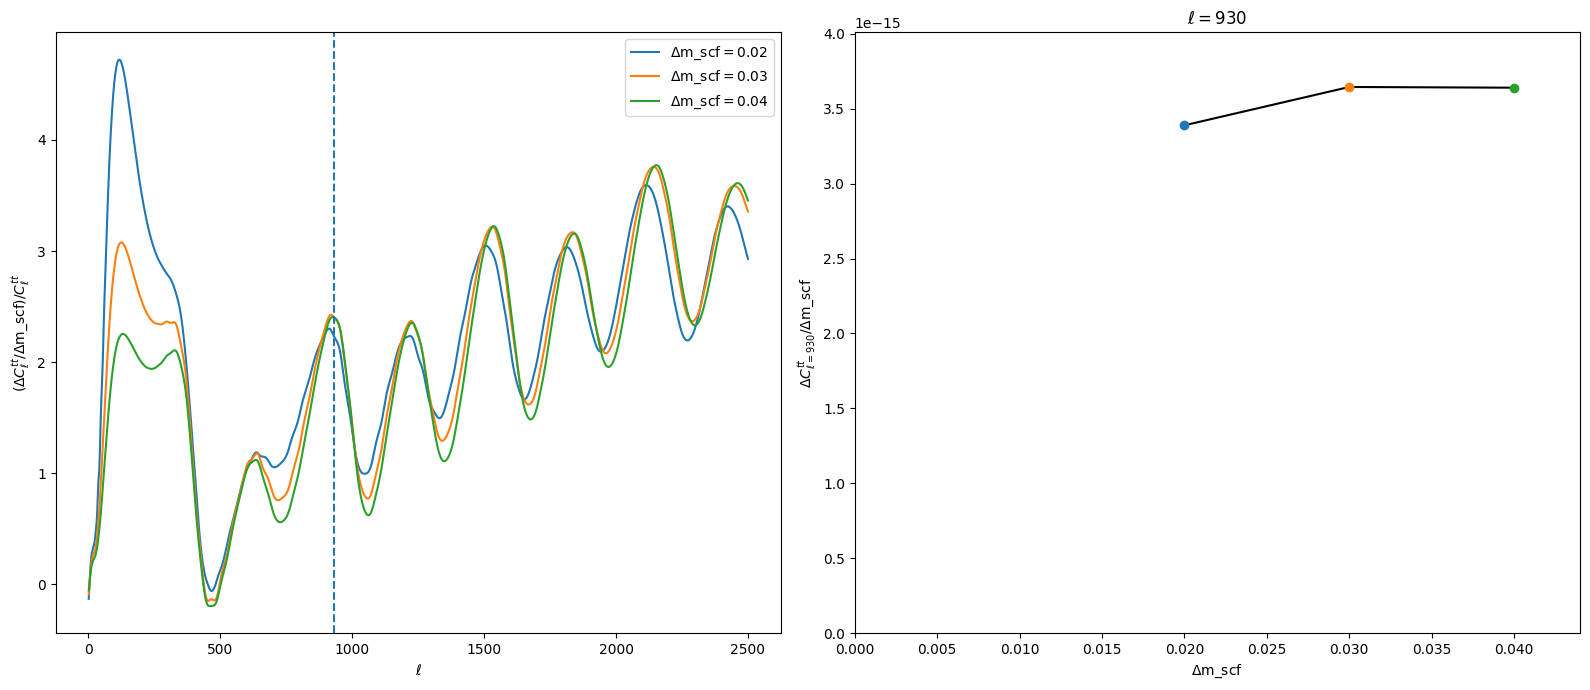

In [13]:
# Use relative steps around phi0 to avoid both too-large and too-small additive perturbations.

obs.check_deriv_compute('m_scf', [2e-2, 3e-2, 4e-2], classy_template, verbose=True)
obs.check_deriv_plot('m_scf', ell=930, l_max=2500)

{'output': 'tCl pCl lCl', 'l_max_scalars': 3500, 'h': 0.6732117, 'omega_b': 0.0223828, 'omega_cdm': 0.12038, 'N_ur': 2.0328, 'omega_ncdm': 0.0006451439, 'N_ncdm': 1, 'm_ncdm': 0.06, 'T_ncdm': 0.71611, 'tau_reio': 0.05430842, 'Omega_k': 0.0, 'A_s': 2.100549e-09, 'n_s': 0.9660499, 'YHe': 0.2454006, 'lensing': 'yes', 'gauge': 'synchronous', 'phi_scf_ini': 1e-05, 'frac_dmde': 0.01001, 'g_scf': -0.013, 'm_scf': 0.01}
{'output': 'tCl pCl lCl', 'l_max_scalars': 3500, 'h': 0.6732117, 'omega_b': 0.0223828, 'omega_cdm': 0.12038, 'N_ur': 2.0328, 'omega_ncdm': 0.0006451439, 'N_ncdm': 1, 'm_ncdm': 0.06, 'T_ncdm': 0.71611, 'tau_reio': 0.05430842, 'Omega_k': 0.0, 'A_s': 2.100549e-09, 'n_s': 0.9660499, 'YHe': 0.2454006, 'lensing': 'yes', 'gauge': 'synchronous', 'phi_scf_ini': 1e-05, 'frac_dmde': 0.02001, 'g_scf': -0.013, 'm_scf': 0.01}
{'output': 'tCl pCl lCl', 'l_max_scalars': 3500, 'h': 0.6732117, 'omega_b': 0.0223828, 'omega_cdm': 0.12038, 'N_ur': 2.0328, 'omega_ncdm': 0.0006451439, 'N_ncdm': 1, 'm

TypeError: argument of type 'NoneType' is not iterable

Exception ignored in: 'classy.Class.__dealloc__'
Traceback (most recent call last):
  File "classy.pyx", line 204, in classy.Class.struct_cleanup
TypeError: argument of type 'NoneType' is not iterable


TypeError: argument of type 'NoneType' is not iterable

Exception ignored in: 'classy.Class.__dealloc__'
Traceback (most recent call last):
  File "classy.pyx", line 204, in classy.Class.struct_cleanup
TypeError: argument of type 'NoneType' is not iterable


...

Exception ignored in: 'classy.Class.__dealloc__'
Traceback (most recent call last):
  File "classy.pyx", line 204, in classy.Class.struct_cleanup
TypeError: argument of type 'NoneType' is not iterable


TypeError: argument of type 'NoneType' is not iterable

Exception ignored in: 'classy.Class.__dealloc__'
Traceback (most recent call last):
  File "classy.pyx", line 204, in classy.Class.struct_cleanup
TypeError: argument of type 'NoneType' is not iterable


TypeError: argument of type 'NoneType' is not iterable

Exception ignored in: 'classy.Class.__dealloc__'
Traceback (most recent call last):
  File "classy.pyx", line 204, in classy.Class.struct_cleanup
TypeError: argument of type 'NoneType' is not iterable


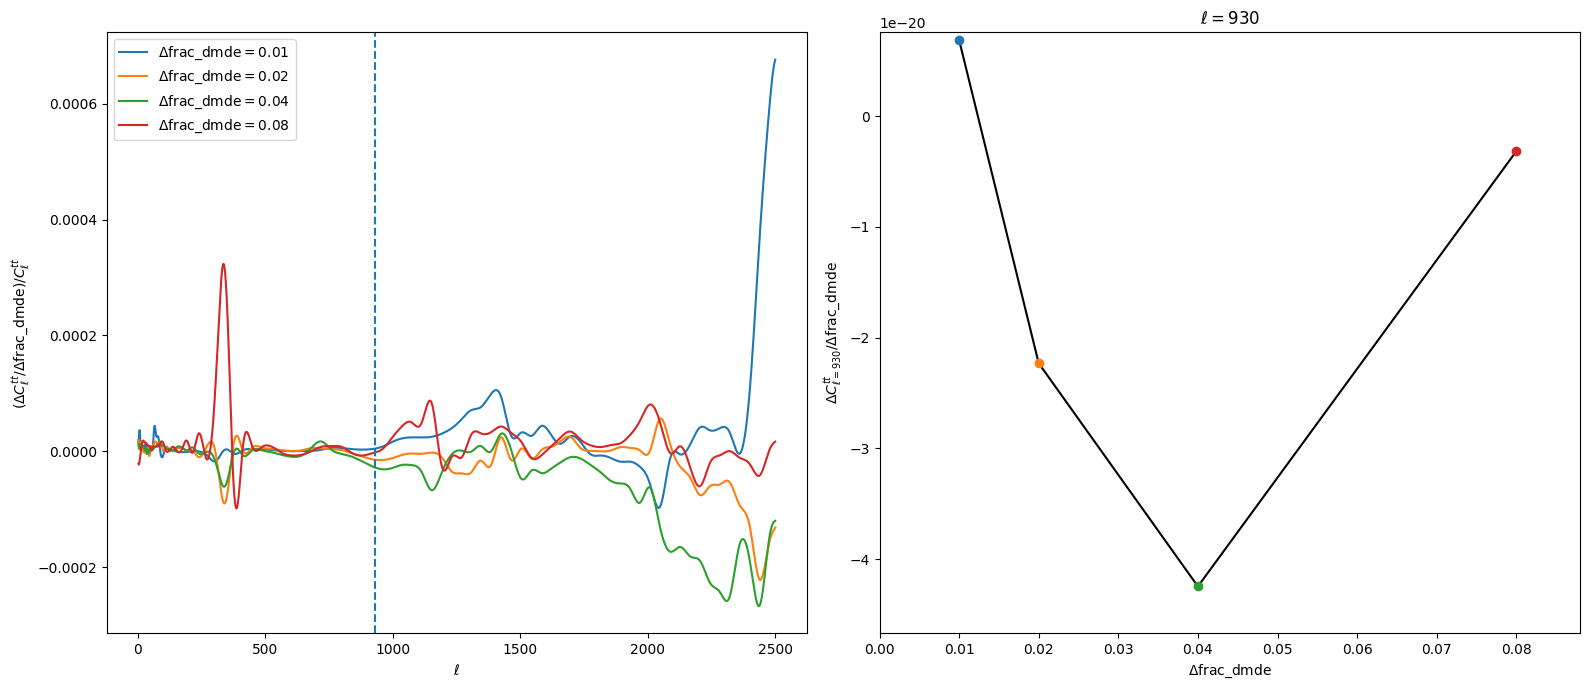

In [26]:
# Use relative steps around phi0 to avoid both too-large and too-small additive perturbations.

obs.check_deriv_compute('frac_dmde', [1e-2, 2e-2, 4e-2, 8e-2], classy_template, verbose=True)
obs.check_deriv_plot('frac_dmde', ell=930, l_max=2500)

{'output': 'tCl pCl lCl', 'l_max_scalars': 3500, 'h': 0.6732117, 'omega_b': 0.0223828, 'omega_cdm': 0.12038, 'N_ur': 2.0328, 'omega_ncdm': 0.0006451439, 'N_ncdm': 1, 'm_ncdm': 0.06, 'T_ncdm': 0.71611, 'tau_reio': 0.05430842, 'Omega_k': 0.0, 'A_s': 2.100549e-09, 'n_s': 0.9660499, 'YHe': 0.2454006, 'lensing': 'yes', 'gauge': 'synchronous', 'phi_scf_ini': 0.02801, 'frac_dmde': 1e-05, 'g_scf': -0.013, 'm_scf': 14.3}
{'output': 'tCl pCl lCl', 'l_max_scalars': 3500, 'h': 0.6732117, 'omega_b': 0.0223828, 'omega_cdm': 0.12038, 'N_ur': 2.0328, 'omega_ncdm': 0.0006451439, 'N_ncdm': 1, 'm_ncdm': 0.06, 'T_ncdm': 0.71611, 'tau_reio': 0.05430842, 'Omega_k': 0.0, 'A_s': 2.100549e-09, 'n_s': 0.9660499, 'YHe': 0.2454006, 'lensing': 'yes', 'gauge': 'synchronous', 'phi_scf_ini': 0.03001, 'frac_dmde': 1e-05, 'g_scf': -0.013, 'm_scf': 14.3}
{'output': 'tCl pCl lCl', 'l_max_scalars': 3500, 'h': 0.6732117, 'omega_b': 0.0223828, 'omega_cdm': 0.12038, 'N_ur': 2.0328, 'omega_ncdm': 0.0006451439, 'N_ncdm': 1, 'm

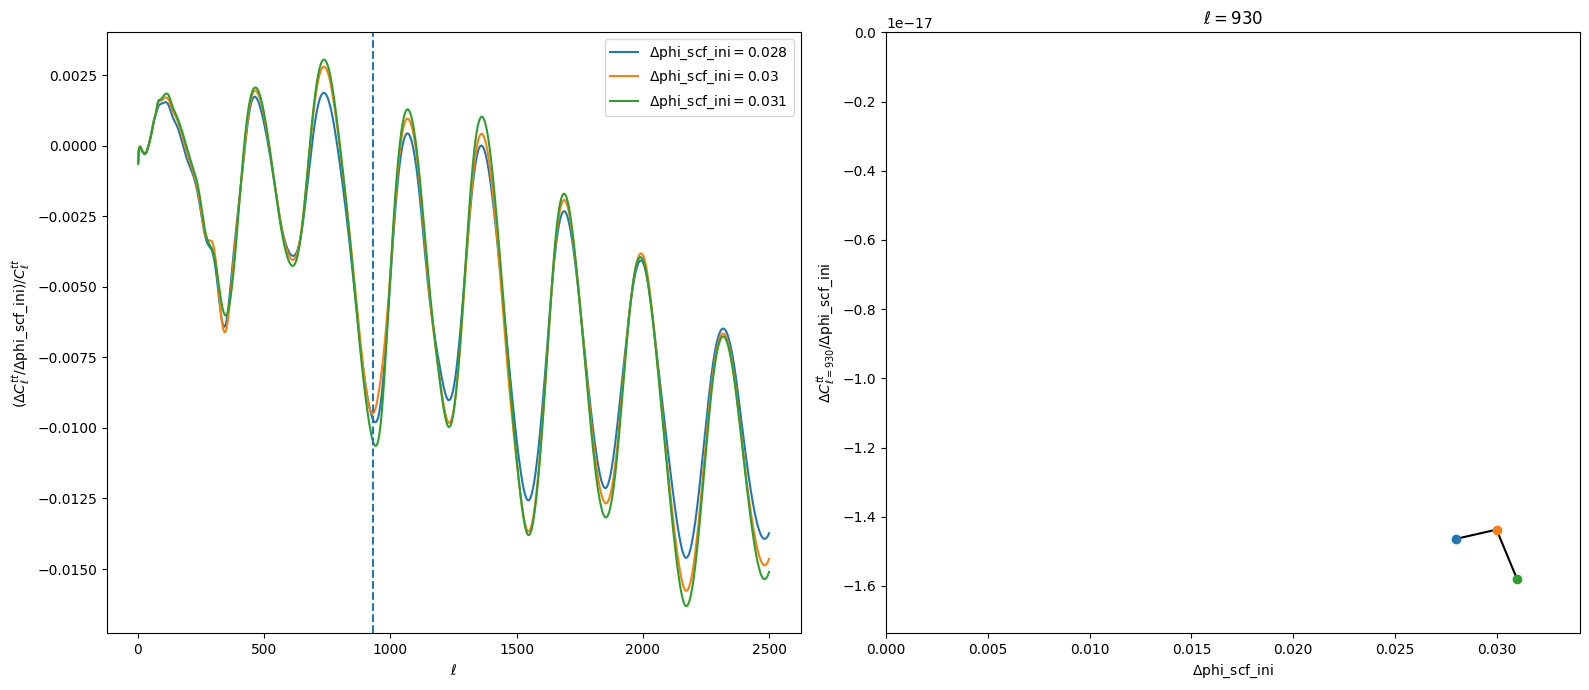

In [30]:
# Use relative steps around phi0 to avoid both too-large and too-small additive perturbations.

obs.check_deriv_compute('phi_scf_ini', [2.8e-2, 3e-2, 3.1e-2], classy_template, verbose=True)
obs.check_deriv_plot('phi_scf_ini', ell=930, l_max=2500)

{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.13010750000000001, 'omega_b': 0.022032, 'Omega_k': 0.0, 'N_ur': 2.0328, 'A_s': 2.215e-09, 'n_s': 0.9619, 'tau_reio': 0.0925}
{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.1401075, 'omega_b': 0.022032, 'Omega_k': 0.0, 'N_ur': 2.0328, 'A_s': 2.215e-09, 'n_s': 0.9619, 'tau_reio': 0.0925}
{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.1501075, 'omega_b': 0.022032, 'Omega_k': 0.0, 'N_ur': 2.0328, 'A_s': 2.215e-09, 'n_s': 0.9619, 'tau_reio': 0.0925}
{'output': 'tCl pCl l

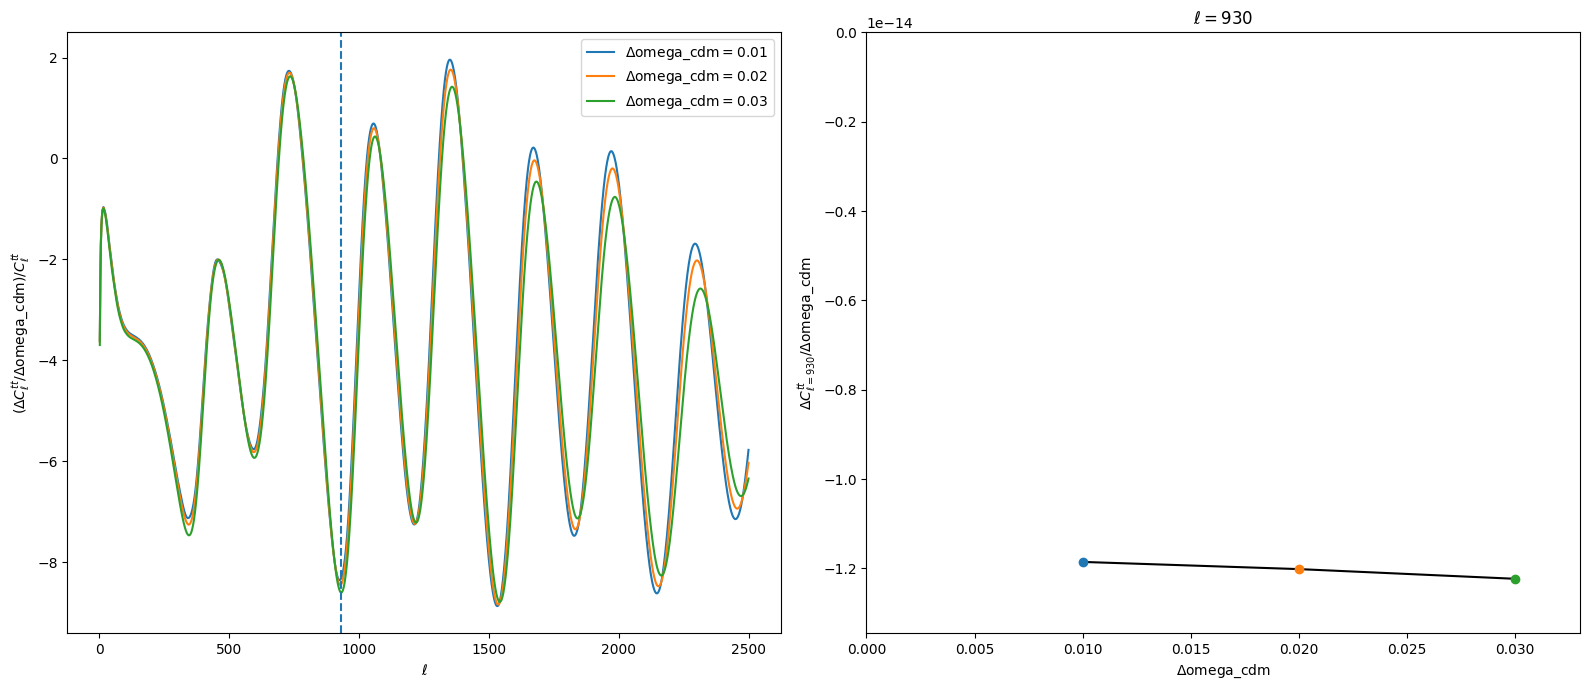

In [29]:
obs.check_deriv_compute("omega_cdm", [0.01, 0.02, 0.03], classy_template, verbose=True)
obs.check_deriv_plot("omega_cdm", ell=930, l_max=2500)

{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.1201075, 'omega_b': 0.023032, 'Omega_k': 0.0, 'N_ur': 2.0328, 'A_s': 2.215e-09, 'n_s': 0.9619, 'tau_reio': 0.0925}
{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.1201075, 'omega_b': 0.024031999999999998, 'Omega_k': 0.0, 'N_ur': 2.0328, 'A_s': 2.215e-09, 'n_s': 0.9619, 'tau_reio': 0.0925}
{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.1201075, 'omega_b': 0.025032, 'Omega_k': 0.0, 'N_ur': 2.0328, 'A_s': 2.215e-09, 'n_s': 0.9619, 'tau_reio': 0.0925}
{'output': 'tCl pCl

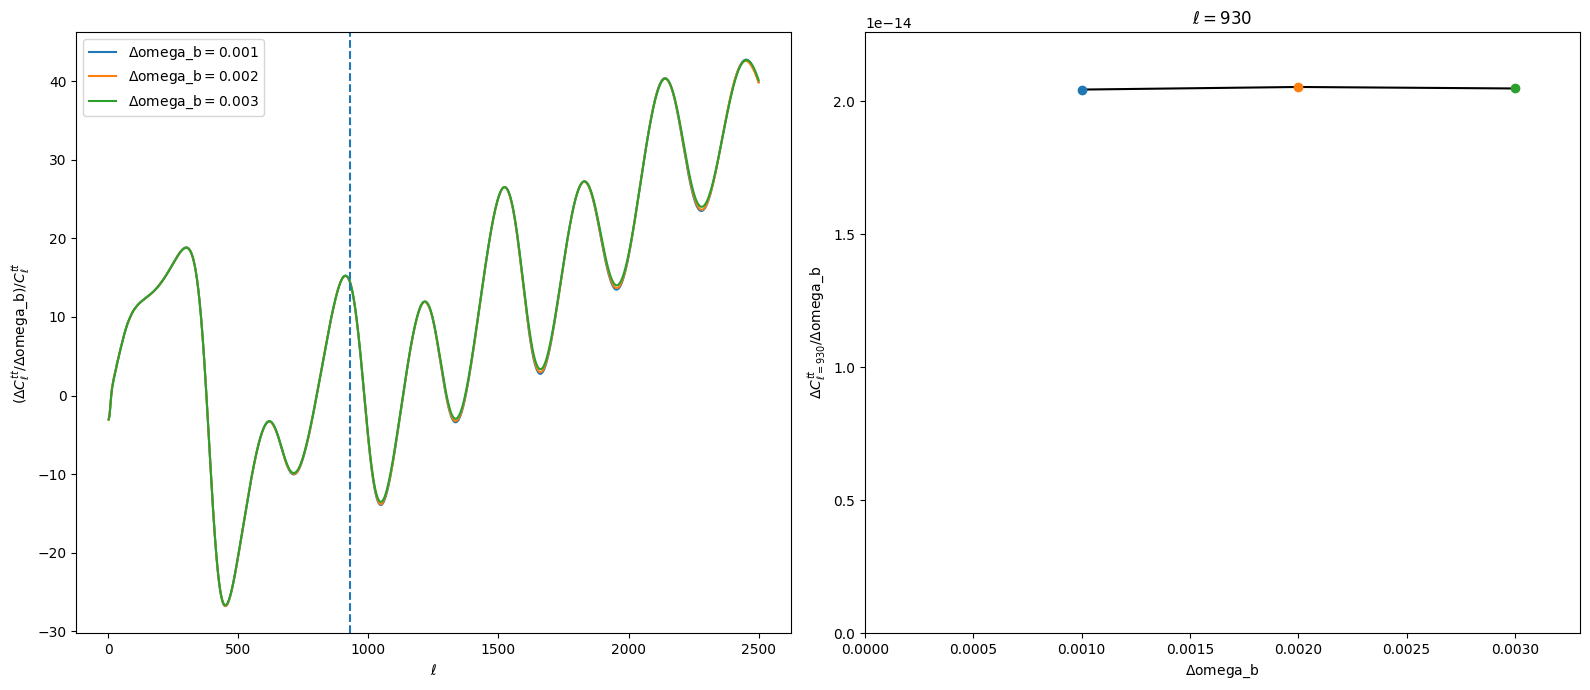

In [32]:
obs.check_deriv_compute("omega_b", [0.001, 0.002, 0.003], classy_template, verbose=True)
obs.check_deriv_plot("omega_b", ell=930, l_max=2500)

{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.1201075, 'omega_b': 0.022032, 'Omega_k': 0.1, 'N_ur': 2.0328, 'A_s': 2.215e-09, 'n_s': 0.9619, 'tau_reio': 0.0925}
{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.1201075, 'omega_b': 0.022032, 'Omega_k': 0.2, 'N_ur': 2.0328, 'A_s': 2.215e-09, 'n_s': 0.9619, 'tau_reio': 0.0925}
{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.1201075, 'omega_b': 0.022032, 'Omega_k': 0.3, 'N_ur': 2.0328, 'A_s': 2.215e-09, 'n_s': 0.9619, 'tau_reio': 0.0925}
{'output': 'tCl pCl lCl', 'l_ma

/home/quantumer/.local/lib/python3.10/site-packages/fishchips/cosmo.py:218: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axes[1].set_ylim(min_y, max_y)


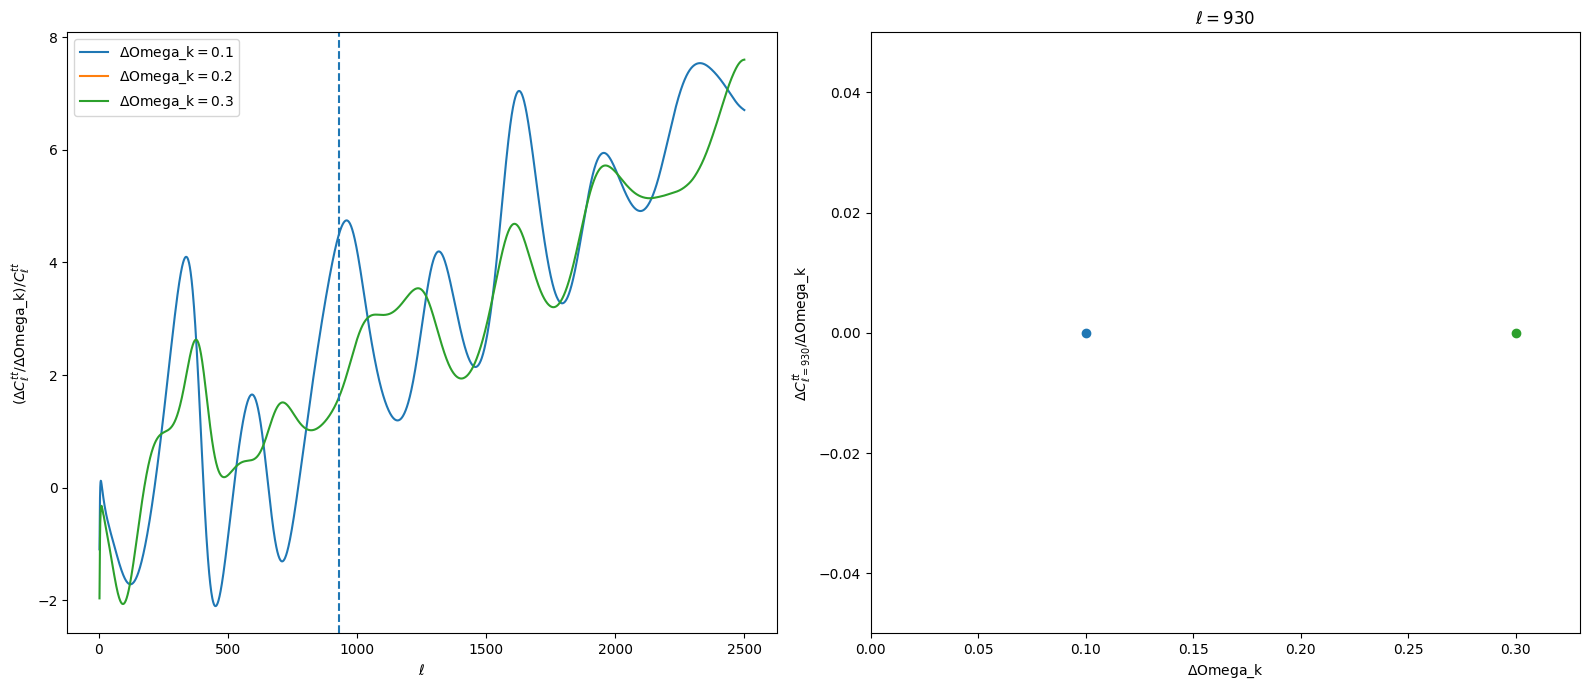

In [34]:
obs.check_deriv_compute("Omega_k", [0.1, 0.2, 0.3], classy_template, verbose=True)
obs.check_deriv_plot("Omega_k", ell=930, l_max=2500)

{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.1201075, 'omega_b': 0.022032, 'Omega_k': 0.0, 'N_ur': 2.1328, 'A_s': 2.215e-09, 'n_s': 0.9619, 'tau_reio': 0.0925}
{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.1201075, 'omega_b': 0.022032, 'Omega_k': 0.0, 'N_ur': 2.2328, 'A_s': 2.215e-09, 'n_s': 0.9619, 'tau_reio': 0.0925}
{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.1201075, 'omega_b': 0.022032, 'Omega_k': 0.0, 'N_ur': 2.3327999999999998, 'A_s': 2.215e-09, 'n_s': 0.9619, 'tau_reio': 0.0925}
{'output': 'tCl pCl

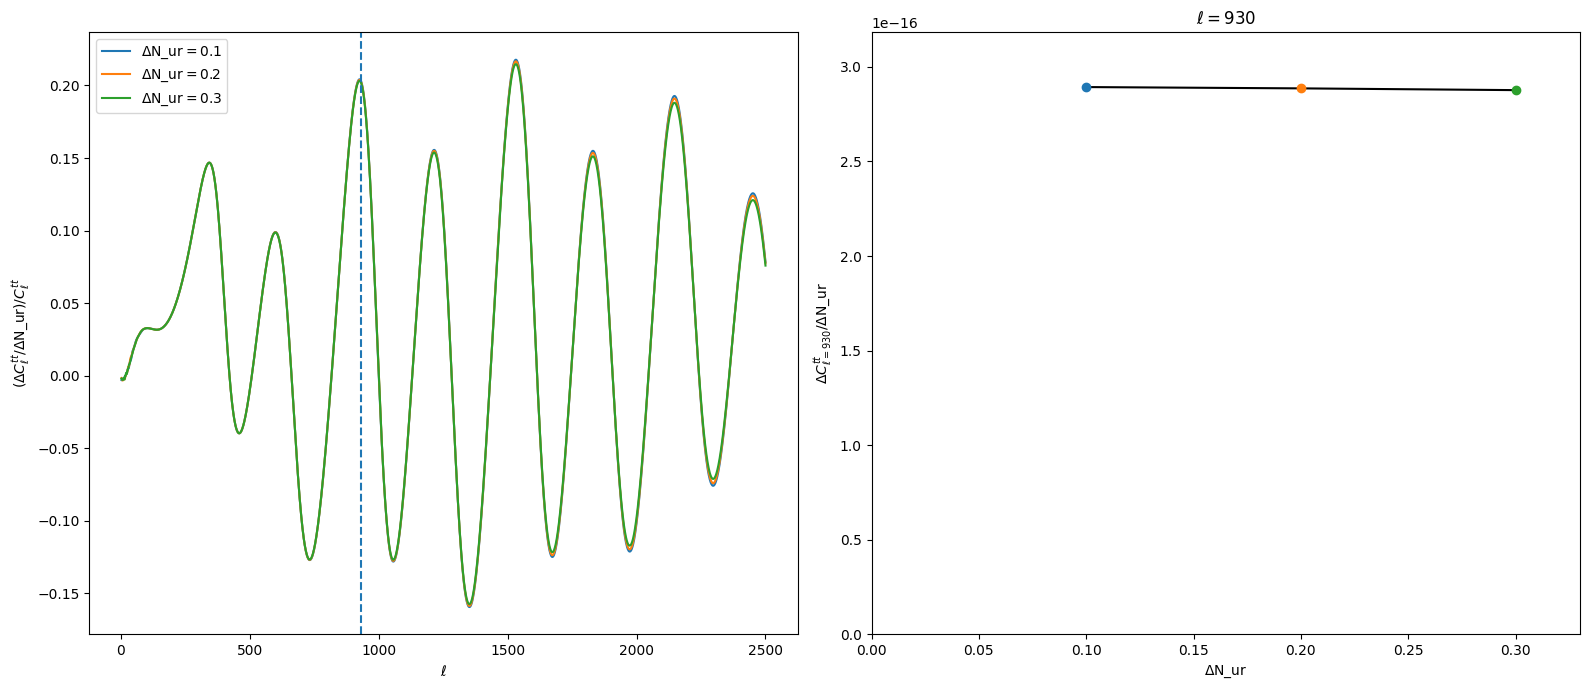

In [35]:
obs.check_deriv_compute("N_ur", [0.1, 0.2, 0.3], classy_template, verbose=True)
obs.check_deriv_plot("N_ur", ell=930, l_max=2500)

{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.1201075, 'omega_b': 0.022032, 'Omega_k': 0.0, 'N_ur': 2.0328, 'A_s': 2.315e-09, 'n_s': 0.9619, 'tau_reio': 0.0925}
{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.1201075, 'omega_b': 0.022032, 'Omega_k': 0.0, 'N_ur': 2.0328, 'A_s': 2.415e-09, 'n_s': 0.9619, 'tau_reio': 0.0925}
{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.1201075, 'omega_b': 0.022032, 'Omega_k': 0.0, 'N_ur': 2.0328, 'A_s': 2.5149999999999997e-09, 'n_s': 0.9619, 'tau_reio': 0.0925}
{'output': 'tCl pC

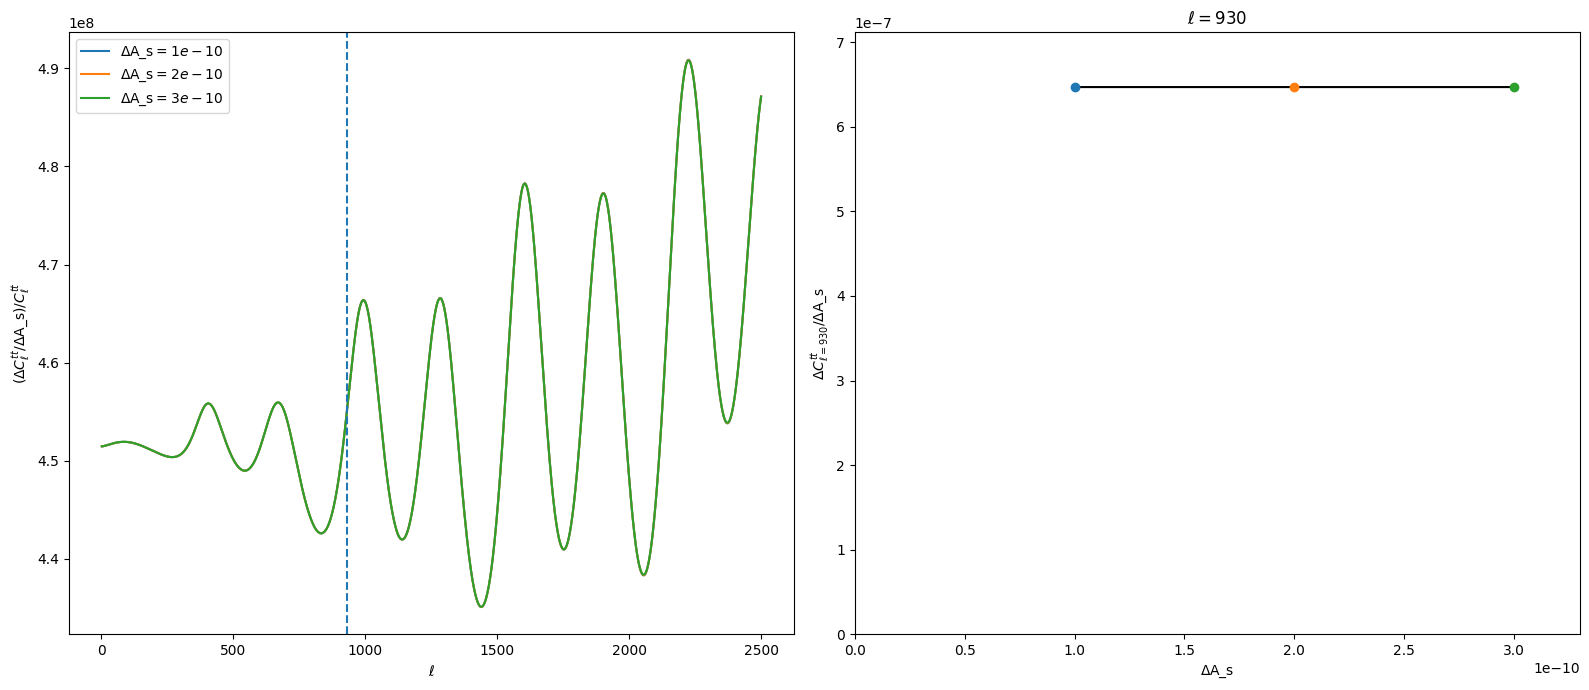

In [36]:
obs.check_deriv_compute("A_s", [1e-10,2e-10,3e-10], classy_template, verbose=True)
obs.check_deriv_plot("A_s", ell=930, l_max=2500)

{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.1201075, 'omega_b': 0.022032, 'Omega_k': 0.0, 'N_ur': 2.0328, 'A_s': 2.215e-09, 'n_s': 0.9719, 'tau_reio': 0.0925}
{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.1201075, 'omega_b': 0.022032, 'Omega_k': 0.0, 'N_ur': 2.0328, 'A_s': 2.215e-09, 'n_s': 0.9819, 'tau_reio': 0.0925}
{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.1201075, 'omega_b': 0.022032, 'Omega_k': 0.0, 'N_ur': 2.0328, 'A_s': 2.215e-09, 'n_s': 0.9919, 'tau_reio': 0.0925}
{'output': 'tCl pCl lCl', 'l_ma

Exception ignored in: Traceback (most recent call last):
'classy.Class.__dealloc__'
Traceback (most recent call last):
  File "classy.pyx", line 204, in classy.Class.struct_cleanup
  File "classy.pyx", line 204, in classy.Class.struct_cleanup
TypeError: argument of type 'NoneType' is not iterable
TypeError: argument of type 'NoneType' is not iterable
Exception ignored in: Traceback (most recent call last):
'classy.Class.__dealloc__'
Traceback (most recent call last):
  File "classy.pyx", line 204, in classy.Class.struct_cleanup
TypeError: argument of type 'NoneType' is not iterable
  File "classy.pyx", line 204, in classy.Class.struct_cleanup
TypeError: argument of type 'NoneType' is not iterable


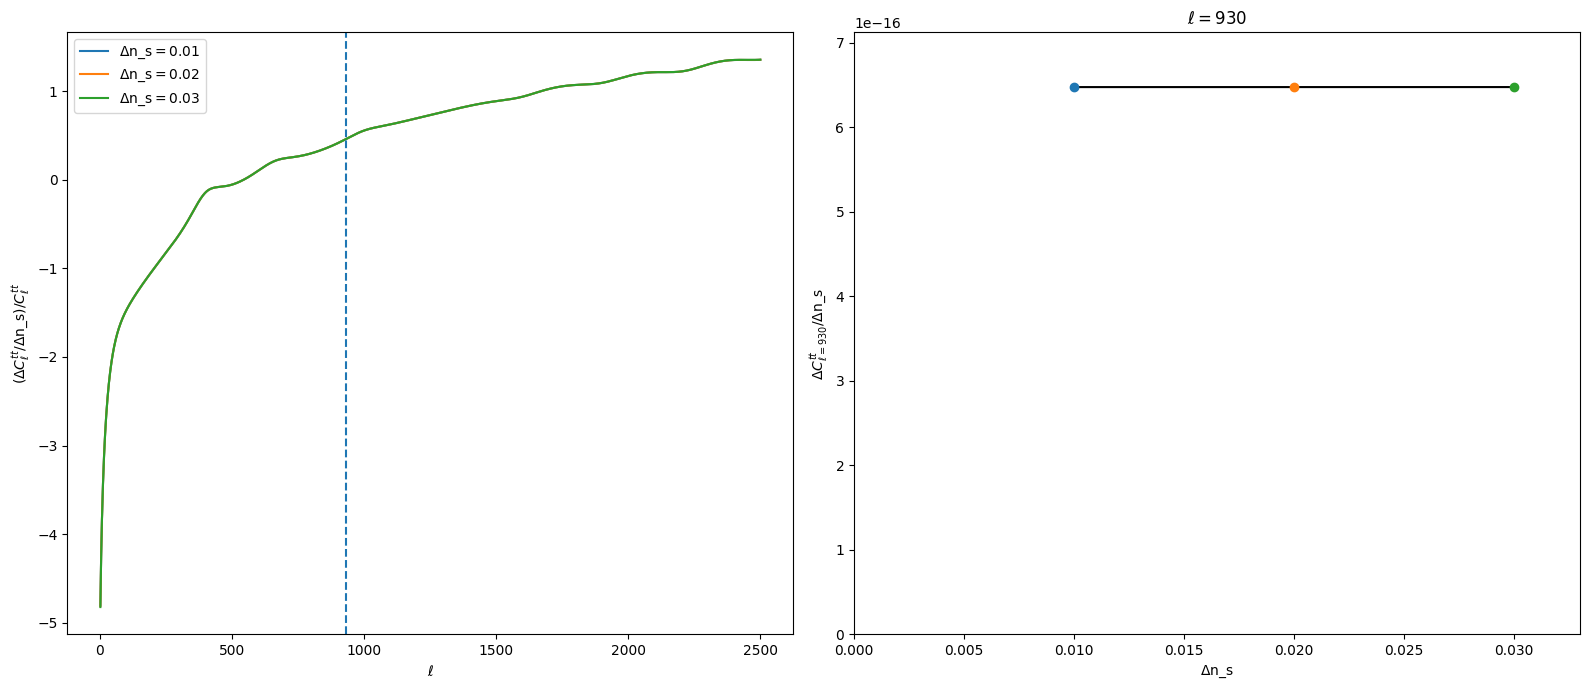

In [37]:
obs.check_deriv_compute("n_s", [0.01,0.02,0.03], classy_template, verbose=True)
obs.check_deriv_plot("n_s", ell=930, l_max=2500)

{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.1201075, 'omega_b': 0.022032, 'Omega_k': 0.0, 'N_ur': 2.0328, 'A_s': 2.215e-09, 'n_s': 0.9619, 'tau_reio': 0.1025}
{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.1201075, 'omega_b': 0.022032, 'Omega_k': 0.0, 'N_ur': 2.0328, 'A_s': 2.215e-09, 'n_s': 0.9619, 'tau_reio': 0.1125}
{'output': 'tCl pCl lCl', 'l_max_scalars': 2500, 'YHe': 0.245, 'lensing': 'yes', 'gauge': 'synchronous', 'h': 0.6732117, 'frac_dmde': 0.8, 'g_scf': -0.013, 'm_scf': 14.3, 'phi_scf_ini': 0.695, 'omega_cdm': 0.1201075, 'omega_b': 0.022032, 'Omega_k': 0.0, 'N_ur': 2.0328, 'A_s': 2.215e-09, 'n_s': 0.9619, 'tau_reio': 0.1225}
{'output': 'tCl pCl lCl', 'l_ma

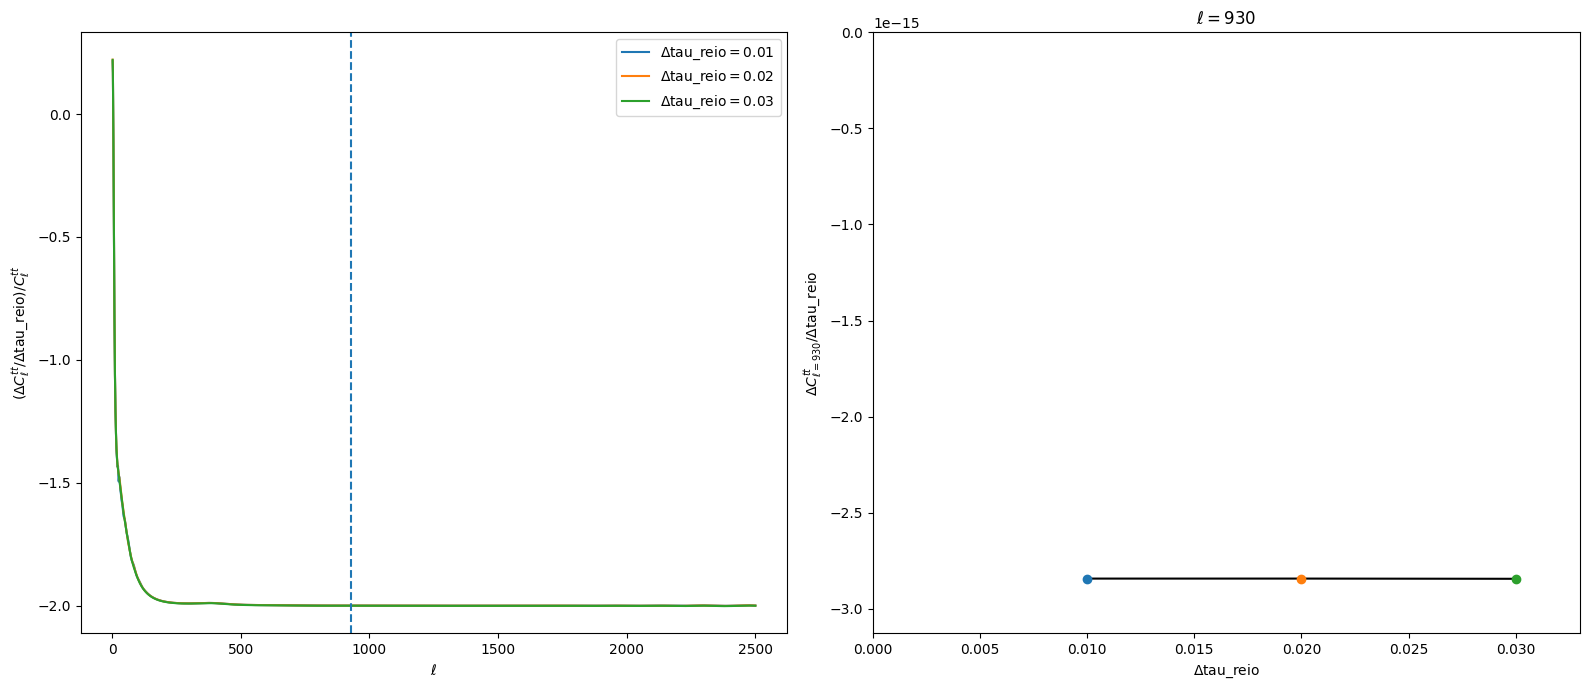

: 

In [38]:
obs.check_deriv_compute("tau_reio", [0.01,0.02,0.03], classy_template, verbose=True)
obs.check_deriv_plot("tau_reio", ell=930, l_max=2500)

We note that the derivative is stable to the stepsize up to a few percent, for an order of magnitude in the step. That's great! This is what we would describe as "converged". A rule of thumb is 20% stability in the derivative for a factor of 2 change in the step size, which is certainly achieved here. Now let's see what happens when we try some huge step sizes.

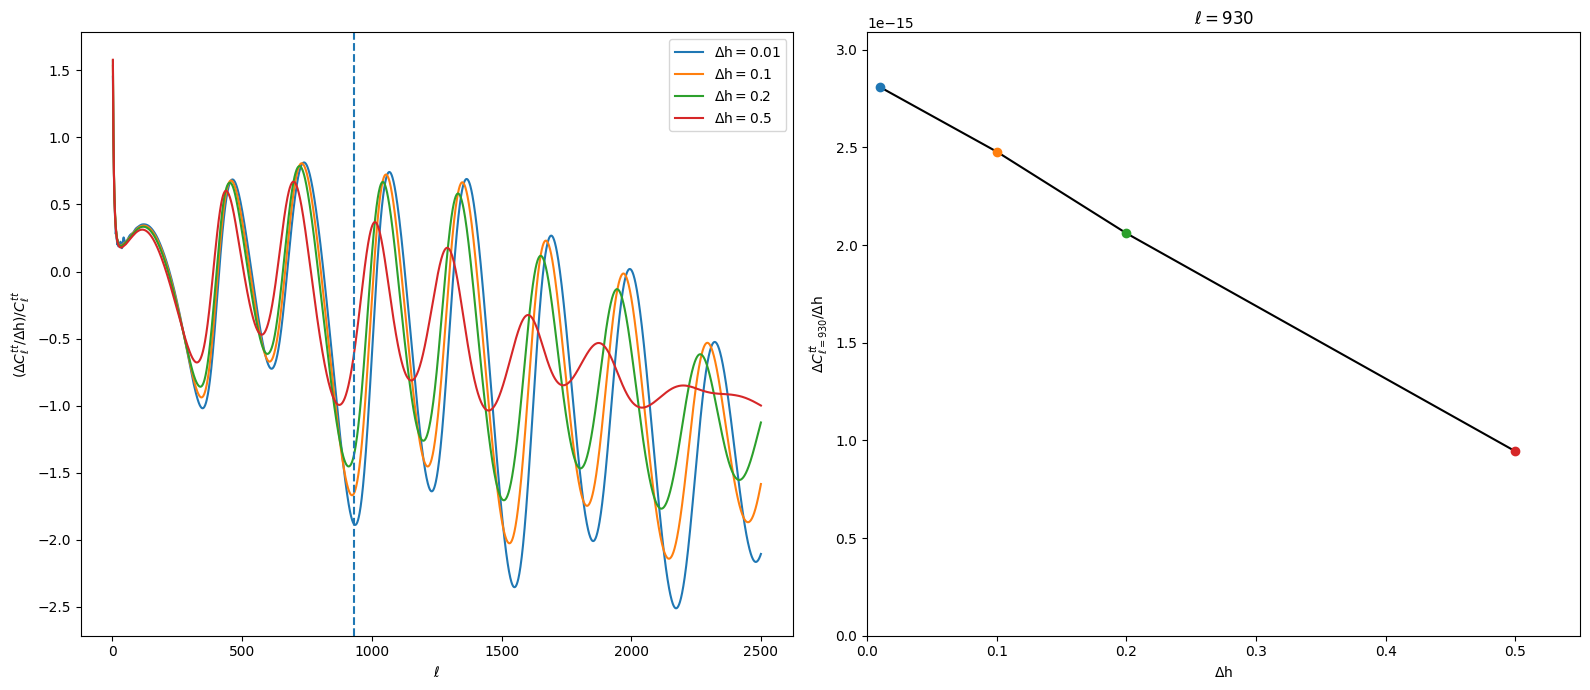

In [16]:
obs.check_deriv_compute("h", [0.01, 0.1, 0.2, 0.5], classy_template)
obs.check_deriv_plot("h", ell=930, l_max=2500)

As you can see, there is a strong dependence on the step when we make the step very large. This is very bad! You've chosen a stepsize that is too large. Now let's see what happens when the stepsize is too small.

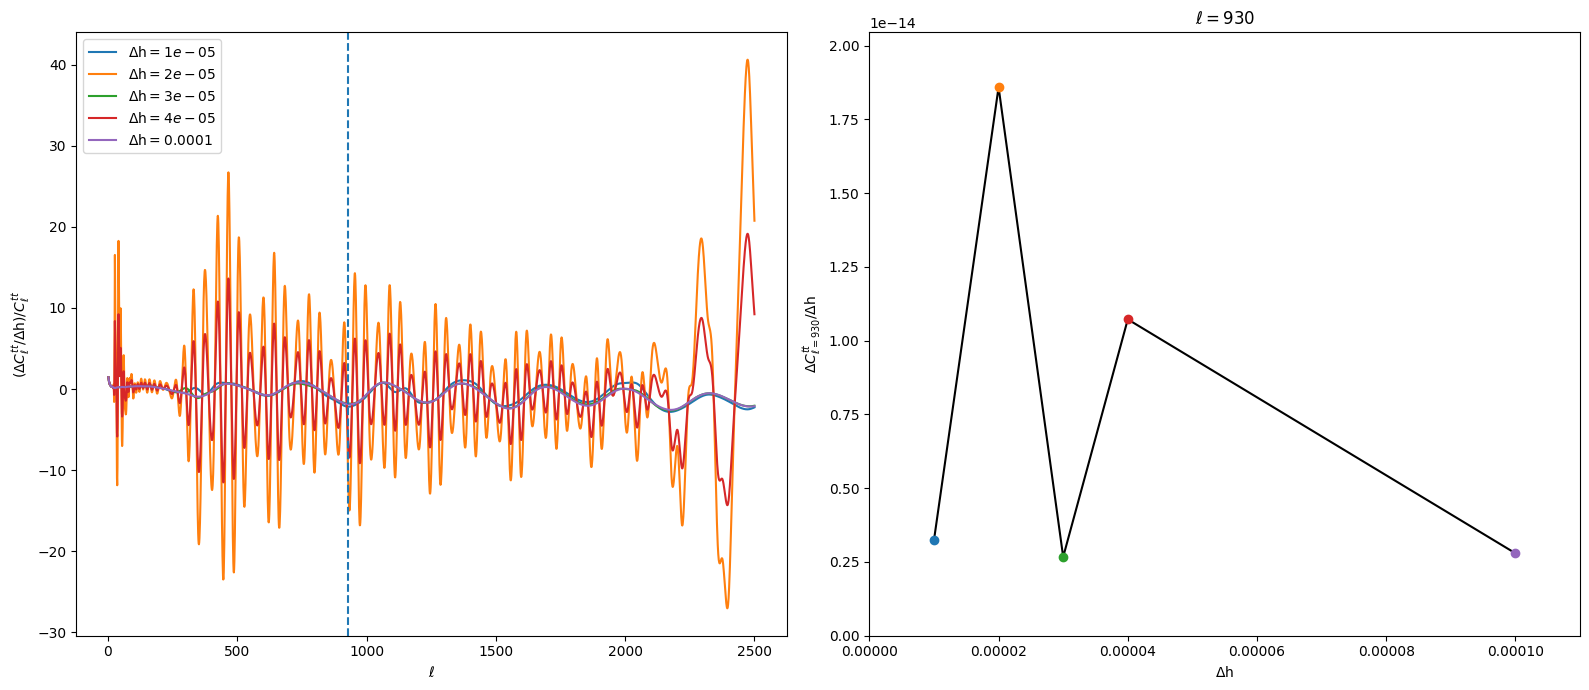

In [7]:
obs.check_deriv_compute("h", [0.00001, 0.00002, 0.00003, 0.00004, 0.0001], classy_template)
obs.check_deriv_plot('h', ell=930, l_max=2500)

Now you are encountering some numerical noise. This is especially evidence for low $\ell$ in the left plot.

**Summary: you have to choose a stepsize that is not too large (so that it is converged) but not too small (where you hit numerical noise).**